In [ ]:
%matplotlib inline

import datetime
import backtrader as bt
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from btplotting import BacktraderPlotting, BacktraderPlottingOptBrowser
from btplotting.schemes import Tradimo


data = yf.download('ORCL', '2000-01-01', '2000-12-31')
# Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
datafeed = bt.feeds.PandasData(dataname=data)

In [ ]:
cerebro = bt.Cerebro()

import analyzers.addAnalyzersList
analyzers.addAnalyzersList.addAnalyzersList(cerebro)


from Strategies.SMA import SMA
strats = cerebro.optstrategy(SMA, maperiod=range(10, 60, 10))

cerebro.adddata(datafeed)

cerebro.broker.setcash(100000.0)
cerebro.addsizer(bt.sizers.FixedSize, stake=10)
cerebro.broker.setcommission(commission=0.001)

results = cerebro.run(maxcpus=1, optreturn=False)


p = BacktraderPlotting(style='bar', scheme=Tradimo())
browser = BacktraderPlottingOptBrowser(p, results)
browser.start()



In [ ]:
cerebro = bt.Cerebro()

from Strategies.MACD import MACD
cerebro.addstrategy(MACD, printlog=True)

cerebro.adddata(datafeed)

cerebro.broker.setcash(100000.0)
cerebro.addsizer(bt.sizers.FixedSize, stake=10)
cerebro.broker.setcommission(commission=0.001)

print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())
results = cerebro.run()
print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())

# Interactive Bokeh plot with btplotting
p = BacktraderPlotting(style='bar', scheme=Tradimo())
cerebro.plot(p)

In [ ]:
cerebro = bt.Cerebro()

CVX = yf.download('CVX', '2000-01-01', '2009-12-31').xs('CVX', level='Ticker', axis=1, drop_level=True)
XOM = yf.download('XOM', '2000-01-01', '2009-12-31').xs('XOM', level='Ticker', axis=1, drop_level=True)

print(CVX.columns)

import statsmodels.api as sm
import numpy as np
alpha, beta = sm.OLS(
    np.log(CVX['Close']), sm.add_constant(np.log(XOM['Close']))
    ).fit().params

from Strategies.Pairs import PairsStrategy, PairPnlAnalyzer
cerebro.addstrategy(PairsStrategy,
                    alpha=alpha, beta=beta, entry = 1)
cerebro.addanalyzer(PairPnlAnalyzer, _name='pairpnl')
analyzers.addAnalyzersList.addAnalyzersList(cerebro)

data_CVX = bt.feeds.PandasData(dataname=CVX, name='CVX')

print(data_CVX)
data_XOM = bt.feeds.PandasData(dataname=XOM, name='XOM')
cerebro.adddata(data_CVX)
cerebro.adddata(data_XOM)

cerebro.broker.setcash(1000.0)
cerebro.addsizer(bt.sizers.FixedSize, stake=10)
cerebro.broker.setcommission(commission=0.001)

print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())
results = cerebro.run()
print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())

p = BacktraderPlotting(style='bar', scheme=Tradimo())
cerebro.plot(p)


analyzer = results[0].analyzers.pairpnl
pnl_over_time = analyzer.get_analysis()


dates = [bt.num2date(dt) for dt in results[0].datas[0].datetime.array[:len(pnl_over_time)]]
pnl_series = pd.Series(pnl_over_time, index=dates)

pnl_series.plot(title='Pairs Trading PnL Over Time', figsize=(20, 8))
plt.xlabel('Date')
plt.ylabel('Profit and Loss')
plt.grid()
plt.show()

print(f"Sharpe Ratio: {results[0].analyzers.sharpe.get_analysis()['sharperatio']}")
print(f"Annualized Return: {results[0].analyzers.annualizedreturn.get_analysis()['annualizedreturn']:.2%}")

Loading BokehJS ...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded data for SPY  from 2020-01-02 00:00:00 to 2024-12-30 00:00:00
Downloaded data for QQQ  from 2020-01-02 00:00:00 to 2024-12-30 00:00:00
Alpha: 1.1789, Beta: 0.8295
Cointegration test p-value: 0.3223 > 0.05 (Not Cointegrated)
Starting Portfolio Value: 100000.00
Fitting OLS model for cointegration...
NormalizedSpread alpha: 1.1789390079639472, beta: 0.8294895958391063
2020-12-30 00:00:00 - Buying 137.0 shares of A and shorting 130.0 shares of B
2021-05-05 00:00:00 - Closing 137.0 shares of A and -130.0 shares of B
2021-06-18 00:00:00 - Buying 127.0 shares of A and shorting 123.0 shares of B
2022-01-07 00:00:00 - Closing 127.0 shares of A and -123.0 shares of B
2022-02-03 00:00:00 - Shorting 119.0 shares of A and buying 121.0 shares of B
2022-11-02 00:00:00 - Stop loss triggered. Closing -119.0 shares of A and 121.0 shares of B
2022-11-03 00:00:00 - Shorting 137.0 shares of A and buying 159.0 shares of B
2023-05-25 00:00:00 - Closing -137.0 shares of A and 159.0 shares of B
2024

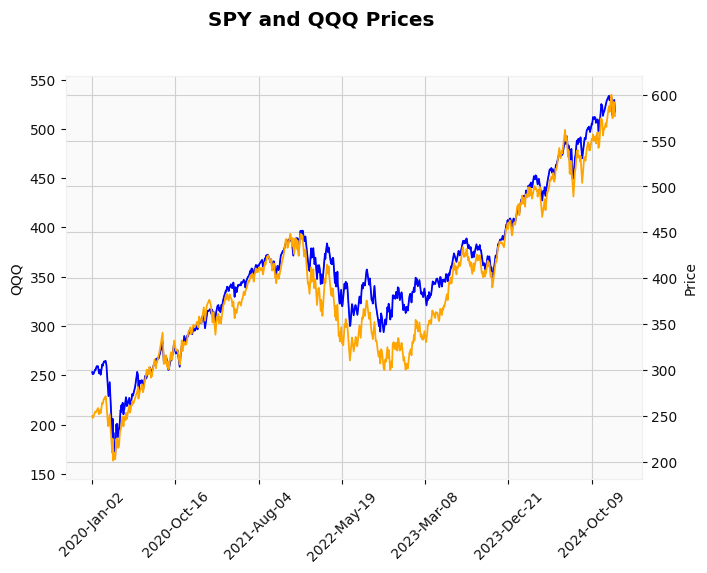

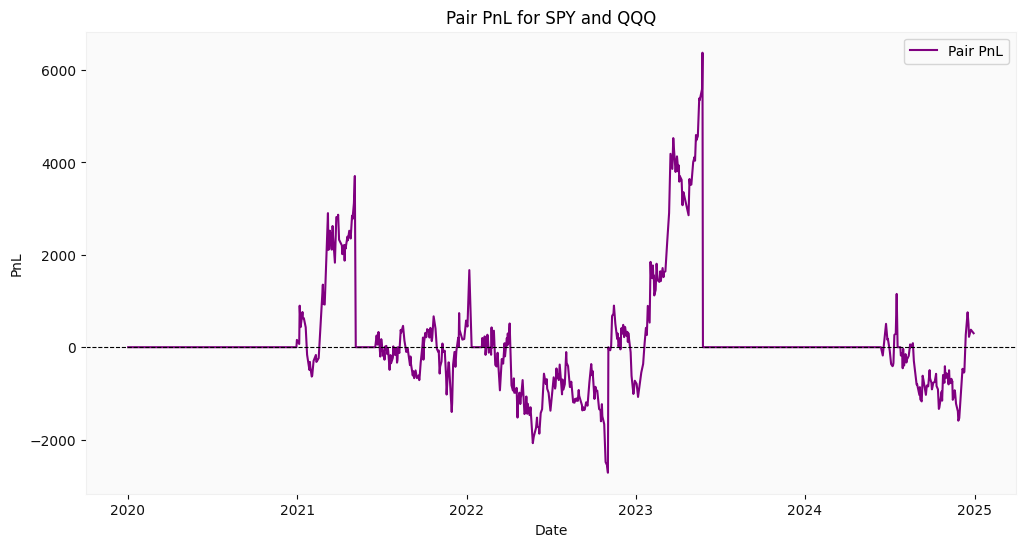

In [1]:
import StrategyWrappers.Pairs

# wrapper = StrategyWrappers.Pairs.PairsWrapper("2021-01-01", "2024-12-31", "SOL-USD", "ETH-USD", verbose=True)
# wrapper = StrategyWrappers.Pairs.PairsWrapper("2021-01-01", "2024-12-31", "JPM", "MS", verbose=True)
wrapper = StrategyWrappers.Pairs.PairsWrapper("2020-01-01", "2024-12-31", "SPY", "QQQ", verbose=True)

wrapper.plot_pair()
wrapper.plot()
wrapper.plot_pnl()